In [40]:
import matplotlib.pyplot as plt
import sys, os
import torch

# Add the project root to the Python path
sys.path.append("..")
os.environ["ROOT_DIR"] = ".."

from agents.maze_agents.toy_maze.env.maze_env import Env
from result_inspection.toy_maze_geodesic import load_laplacian_encoder
from result_inspection.toy_maze import visualize_laplacian_embedding

from geometry_aware_skill_discovery.laplacian_metric import LaplacianMetricCalculator

# Auto-reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Laplacian Representation Visualization
Visualize the learned Laplacian embedding to verify if it captures the topological structure of the maze.

Loading environment: spiral...
Loaded Laplacian Metric Calculator for spiral/random_walk
Sorted Eigenvalues: [ 0.0043  0.0044  0.012   0.0251  0.0272  0.0472  0.0837  0.085   0.0984
  0.1197]
Loading Laplacian Encoder for spiral...
Model for spiral not found. Please train it first using train_laplacian_encoder.py
Computing t-SNE for Commute and Diffusion spaces...


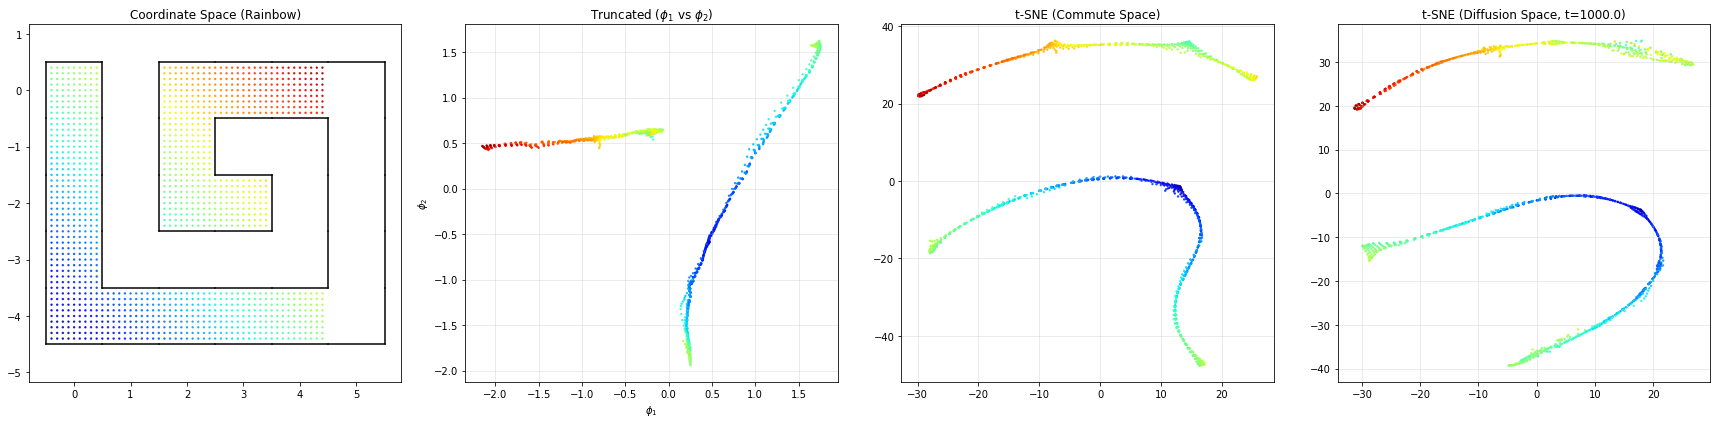

In [45]:
# 1. Setup Environment and Model
maze_type = "spiral"  # Change this to 'square_a' or 'spiral' if needed
exp_type = "random_walk"
print("Loading environment: {}...".format(maze_type))
env = Env(n=1, maze_type=maze_type, use_antigoal=False)
calc = LaplacianMetricCalculator(maze_type=maze_type, exp_name=exp_type)
metric_fn = lambda S, s0: calc.calculate_distance(S, s0, mode="commute")

print("Loading Laplacian Encoder for {}...".format(maze_type))
try:
    phi_encoder = load_laplacian_encoder(maze_type=maze_type)
    print("Model loaded successfully.")
except FileNotFoundError:
    print("Model for {} not found. Please train it first using train_laplacian_encoder.py".format(maze_type))
    # Fallback for testing if model doesn't exist (random encoder)
    # phi_encoder = lambda x: torch.randn(x.shape[0], 20)

# 2. Visualize Embedding
if 'phi_encoder' in locals():
    fig, ax_arr = plt.subplots(1, 4, figsize=(24, 6))
    visualize_laplacian_embedding(env, calc, grid_resolution=0.1, t=1000.0, ax_arr=ax_arr)
    plt.tight_layout()
    plt.show()